
# Multiple Biomarkers of Aging

This notebook explores DNA methylation–based biomarkers of aging using EPIC array datasets. The primary objective is to evaluate and compare multiple epigenetic aging clocks across two independent datasets, assessing their performance through correlation analysis, visualization (heatmaps), and age prediction accuracy.

We leverage the Biolearn library—an open-source Python framework developed by the Biomarkers of Aging Consortium. Biolearn provides standardized implementations of widely used aging clocks and enables direct access to publicly available methylation data from Gene Expression Omnibus (GEO), eliminating the need for manual data download or preprocessing.

By the end of this notebook, you will:

* Apply multiple epigenetic clocks to real-world datasets
* Compare their outputs using statistical and visual methods
* Interpret differences in biological age predictions across models

**Reference:**
Ying et al. (2023). *Biolearn: An open-source library for biomarkers of aging*. bioRxiv. [https://doi.org/10.1101/2023.12.02.569722](https://doi.org/10.1101/2023.12.02.569722)


In [19]:
!pip install biolearn -q

In [20]:
import biolearn
print(f"biolearn version: {biolearn.__version__}")


biolearn version: 0.9.1


## Imports

We import the three core biolearn functions we need for this assignment. DataLibrary handles loading GEO datasets. ModelGallery gives us access to all the aging clock implementations. The three visualize functions directly produce the three plots the assignment asks for.

In [21]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery
from biolearn.visualize import (
    plot_clock_correlation_matrix,
    plot_clock_deviation_heatmap,
    plot_age_prediction
)

print("All imports successful.")

All imports successful.


In [30]:
import os
os.makedirs("figures", exist_ok=True)
print("figures/ directory ready")


figures/ directory ready


## Dataset Selection

We selected two blood DNA methylation datasets from the Biolearn data library, both measured on Illumina 450k/EPIC arrays and both containing chronological age metadata for all samples.

**Dataset 1: GSE120307**
A blood methylation dataset spanning a broad age range. This is the dataset used in the official Biolearn documentation examples, making it a well validated choice. It was profiled using the Illumina 450k array platform.

**Dataset 2: GSE41169**
A blood DNA methylation dataset with 95 samples measured on the Illumina 450k array, from a Dutch population study. It has a good age range with both age and sex metadata present, making it fully compatible with all the aging clocks we are using.

In [23]:
print("Loading Dataset 1: GSE120307 ...")
data1 = DataLibrary().get("GSE120307").load()
print(f"Samples: {data1.metadata.shape[0]}, CpG sites: {data1.dnam.shape[0]}")
print(f"Age range: {data1.metadata['age'].min():.1f} to {data1.metadata['age'].max():.1f} years")
print()
print("Loading Dataset 2: GSE41169 ...")
data2 = DataLibrary().get("GSE41169").load()
print(f"Samples: {data2.metadata.shape[0]}, CpG sites: {data2.dnam.shape[0]}")
print(f"Age range: {data2.metadata['age'].min():.1f} to {data2.metadata['age'].max():.1f} years")

Loading Dataset 1: GSE120307 ...
Samples: 34, CpG sites: 485512
Age range: 19.0 to 54.0 years

Loading Dataset 2: GSE41169 ...
Samples: 95, CpG sites: 485577
Age range: 18.0 to 65.0 years


## Exploratory Data Analysis

Before applying any clocks, we inspect the datasets to understand their structure, age distributions, and any missing values. This confirms the data loaded correctly and gives us biological context for interpreting the clock outputs.


Dataset: GSE120307
  Samples         : 34
  CpG sites       : 485512
  Metadata columns: ['tissue', 'pair_number', 'sex', 'age', 'diagnosis']
  Missing values  : {'tissue': 0, 'pair_number': 0, 'sex': 0, 'age': 0, 'diagnosis': 0}
  Age range       : 19.0 – 54.0 years
  Mean age        : 35.5 years  |  SD: 11.0 years
  Sex breakdown   : {1: 18, 0: 16}

Dataset: GSE41169
  Samples         : 95
  CpG sites       : 485577
  Metadata columns: ['sex', 'age', 'disease']
  Missing values  : {'sex': 0, 'age': 0, 'disease': 0}
  Age range       : 18.0 – 65.0 years
  Mean age        : 31.6 years  |  SD: 10.3 years
  Sex breakdown   : {1: 67, 0: 28}



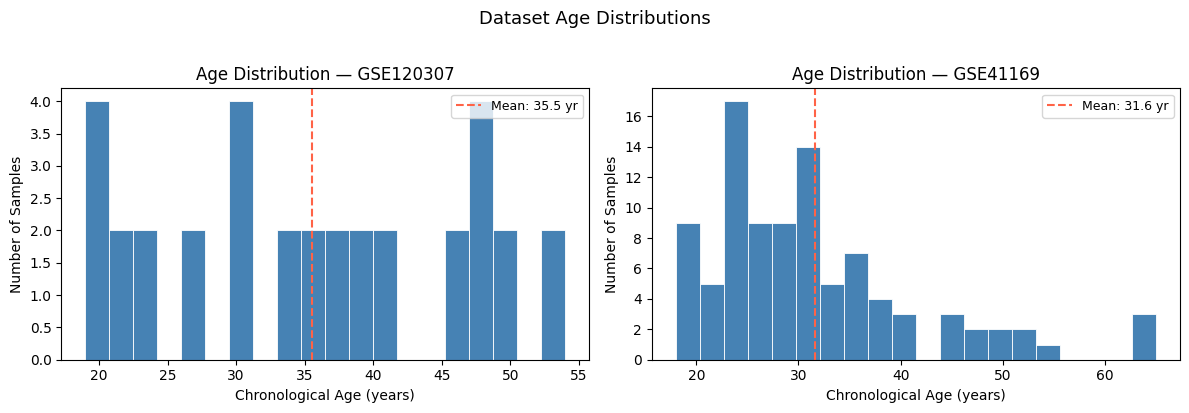

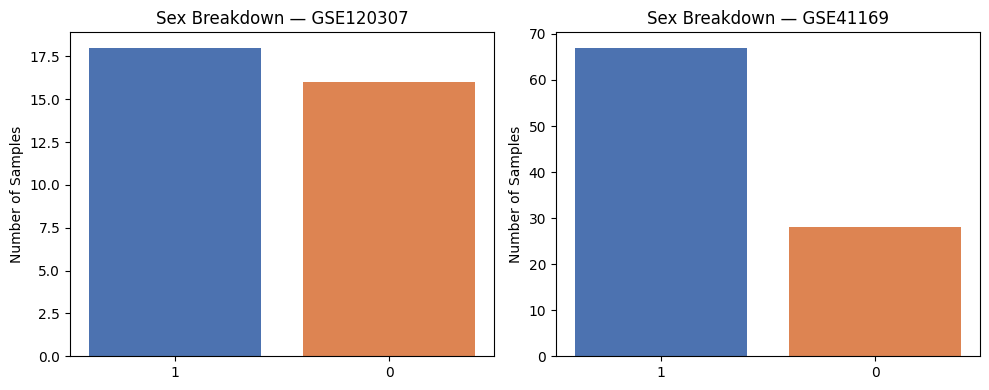

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Shape and missing value summary ────────────────────────────────────
for label, data in [("GSE120307", data1), ("GSE41169", data2)]:
    meta = data.metadata
    print(f"{'='*50}")
    print(f"Dataset: {label}")
    print(f"  Samples         : {meta.shape[0]}")
    print(f"  CpG sites       : {data.dnam.shape[0]}")
    print(f"  Metadata columns: {list(meta.columns)}")
    print(f"  Missing values  : {meta.isnull().sum().to_dict()}")
    print(f"  Age range       : {meta['age'].min():.1f} – {meta['age'].max():.1f} years")
    print(f"  Mean age        : {meta['age'].mean():.1f} years  |  SD: {meta['age'].std():.1f} years")
    if 'sex' in meta.columns:
        print(f"  Sex breakdown   : {meta['sex'].value_counts().to_dict()}")
    print()

# ── Age distribution histograms ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, data) in zip(axes, [("GSE120307", data1), ("GSE41169", data2)]):
    ages = data.metadata['age'].dropna()
    ax.hist(ages, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
    ax.axvline(ages.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean: {ages.mean():.1f} yr')
    ax.set_title(f"Age Distribution — {label}", fontsize=12)
    ax.set_xlabel("Chronological Age (years)")
    ax.set_ylabel("Number of Samples")
    ax.legend(fontsize=9)
fig.suptitle("Dataset Age Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/eda_age_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Sex breakdown bar charts (when metadata is available) ───────────────
datasets_with_sex = [(lbl, d) for lbl, d in [("GSE120307", data1), ("GSE41169", data2)]
                     if 'sex' in d.metadata.columns]
if datasets_with_sex:
    fig, axes = plt.subplots(1, len(datasets_with_sex), figsize=(5 * len(datasets_with_sex), 4))
    if len(datasets_with_sex) == 1:
        axes = [axes]
    for ax, (lbl, d) in zip(axes, datasets_with_sex):
        counts = d.metadata['sex'].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color=['#4C72B0', '#DD8452'])
        ax.set_title(f"Sex Breakdown — {lbl}", fontsize=12)
        ax.set_ylabel("Number of Samples")
    plt.tight_layout()
    plt.savefig("figures/eda_sex_breakdown.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Sex metadata not available in either dataset.")


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Aging Clock Selection

An epigenetic aging clock is a mathematical model that predicts biological or chronological age from DNA methylation patterns at specific CpG sites. Different clocks were trained on different datasets, tissues, and to predict different outcomes.

We selected 8 clocks that span three generations of clock development:

**Horvathv1 (2013)** — The original pan-tissue clock trained on 353 CpGs across 51 tissue types. The most cited aging clock in the field and the baseline everyone compares against.

**Hannum (2013)** — Blood specific clock using 71 CpGs from Illumina 450k data. Developed at the same time as Horvath but designed exclusively for blood.

**PhenoAge (2018)** — A second generation clock trained to predict phenotypic age using clinical biomarkers as an intermediate. Has stronger association with mortality and disease than first generation clocks.

**DunedinPACE (2022)** — Does not predict age in years. Instead it predicts the pace of aging as a rate (e.g. 0.9 means aging 10% slower than average). This is a fundamentally different concept from the other clocks.

**Lin (2016)** — A blood specific clock using 99 CpGs. Designed specifically to work well on blood tissue.

**Zhang_10 (2019)** — A mortality associated clock using only 10 CpGs. Demonstrates how much predictive power is possible with a minimal marker set.

**YingCausAge (2022)** — A causality enriched clock. Rather than selecting CpGs that merely correlate with age, it targets CpGs with causal links to aging.

**YingDamAge (2022)** — Also causality enriched, but specifically targets methylation changes associated with biological damage accumulation during aging.

In [26]:
clock_names = [
    "Horvathv1",
    "Hannum",
    "PhenoAge",
    "DunedinPACE",
    "Lin",
    "Zhang_10",
    "YingCausAge",
    "YingDamAge",
]

gallery = ModelGallery()
models = [gallery.get(name) for name in clock_names]
print(f"Loaded {len(models)} aging clocks successfully.")

Loaded 8 aging clocks successfully.


## Clock Metadata: CpG Counts and Training Cohorts

To contextualise the benchmarking results, we document key properties of each clock—number of CpG sites, training tissue/cohort, and the biological outcome each clock was designed to predict.


In [27]:
# CpG counts and training details for each clock
# (sourced from the original publications; biolearn does not always expose this programmatically)
clock_metadata = {
    "Horvathv1"  : {"CpGs": 353,  "tissue": "Pan-tissue (51 types)",     "trained_on": "~8,000 samples, multi-cohort",  "predicts": "Chronological age"},
    "Hannum"     : {"CpGs": 71,   "tissue": "Blood",                     "trained_on": "~450 blood samples",             "predicts": "Chronological age"},
    "PhenoAge"   : {"CpGs": 513,  "tissue": "Blood",                     "trained_on": "InCHIANTI + NHANES",             "predicts": "Phenotypic age (composite clinical)"},
    "DunedinPACE": {"CpGs": 173,  "tissue": "Blood",                     "trained_on": "Dunedin cohort (NZ)",            "predicts": "Pace of aging (rate, not years)"},
    "Lin"        : {"CpGs": 99,   "tissue": "Blood",                     "trained_on": "~1,000 blood samples",           "predicts": "Chronological age"},
    "Zhang_10"   : {"CpGs": 10,   "tissue": "Blood",                     "trained_on": "UK Biobank subset",             "predicts": "Mortality risk / biological age"},
    "YingCausAge": {"CpGs": 347,  "tissue": "Blood",                     "trained_on": "Multi-cohort (causal CpGs)",     "predicts": "Causal aging signal"},
    "YingDamAge" : {"CpGs": 297,  "tissue": "Blood",                     "trained_on": "Multi-cohort (damage CpGs)",     "predicts": "Biological damage accumulation"},
}

meta_df = pd.DataFrame(clock_metadata).T
meta_df.index.name = "Clock"
print(meta_df.to_string())


            CpGs                 tissue                    trained_on                             predicts
Clock                                                                                                     
Horvathv1    353  Pan-tissue (51 types)  ~8,000 samples, multi-cohort                    Chronological age
Hannum        71                  Blood            ~450 blood samples                    Chronological age
PhenoAge     513                  Blood            InCHIANTI + NHANES  Phenotypic age (composite clinical)
DunedinPACE  173                  Blood           Dunedin cohort (NZ)      Pace of aging (rate, not years)
Lin           99                  Blood          ~1,000 blood samples                    Chronological age
Zhang_10      10                  Blood             UK Biobank subset      Mortality risk / biological age
YingCausAge  347                  Blood    Multi-cohort (causal CpGs)                  Causal aging signal
YingDamAge   297                  Blo

## Correlation Matrix Across Aging Clocks

The correlation matrix shows how strongly each pair of clocks agree with each other across all samples. A high correlation (close to 1.0) between two clocks means they tend to rank samples similarly by predicted age. A low correlation means they are capturing different biological signals.

First generation chronological clocks like Horvathv1 and Hannum are expected to correlate more strongly with each other. DunedinPACE is expected to show lower correlations since it measures pace of aging rather than absolute age in years. We produce this separately for both datasets to see if the inter-clock relationships are consistent across cohorts.

Dataset 1: GSE120307


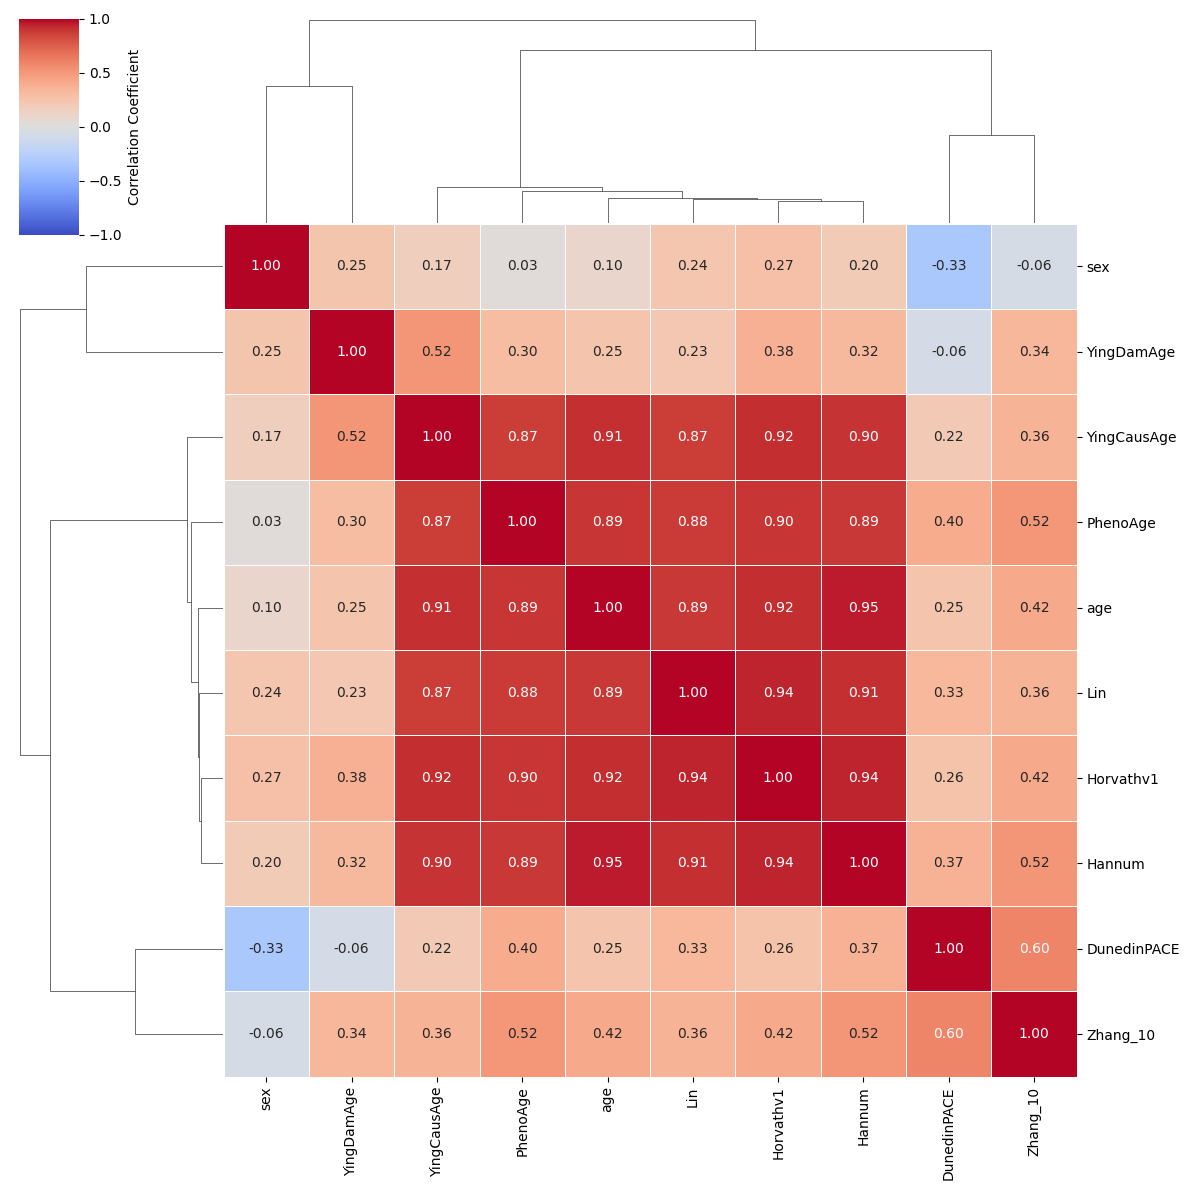

<Figure size 640x480 with 0 Axes>

In [31]:
print("Dataset 1: GSE120307")
plot_clock_correlation_matrix(models=models, data=data1)
plt.suptitle("Clock Correlation Matrix — GSE120307", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/correlation_matrix_GSE120307.png", dpi=150, bbox_inches='tight')
plt.show()

Dataset 2: GSE41169


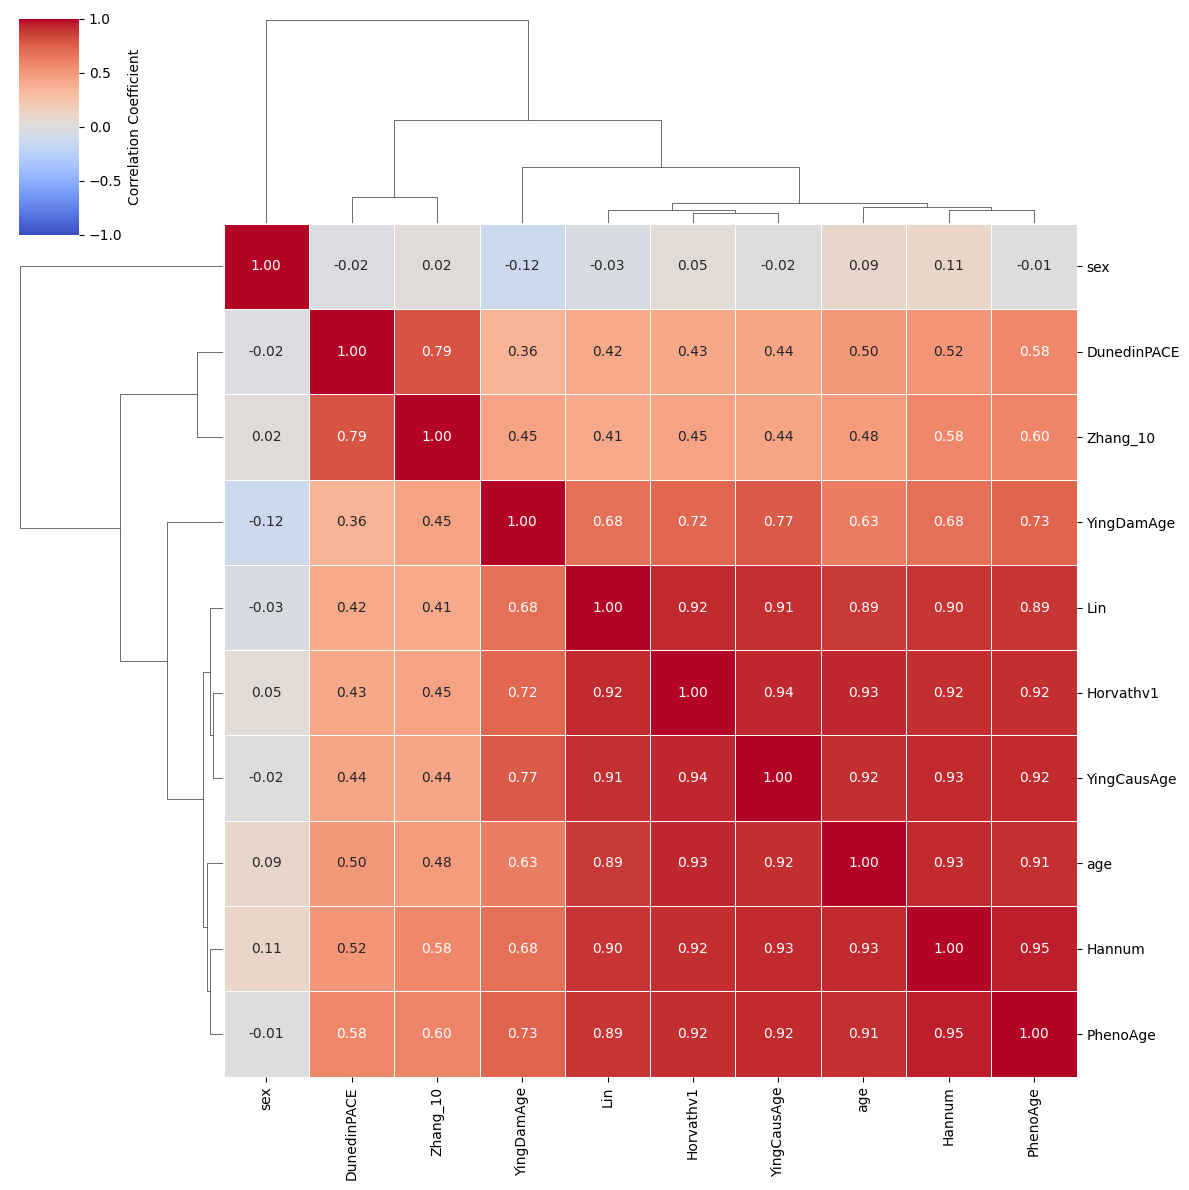

<Figure size 640x480 with 0 Axes>

In [32]:
print("Dataset 2: GSE41169")
plot_clock_correlation_matrix(models=models, data=data2)
plt.suptitle("Clock Correlation Matrix — GSE41169", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/correlation_matrix_GSE41169.png", dpi=150, bbox_inches='tight')
plt.show()

## Clock Predictions vs Chronological Age

These scatter plots show each clock's predicted age on the y-axis against the sample's true chronological age on the x-axis. Each dot is one sample. A perfect clock would place all dots exactly on the diagonal line where predicted age equals actual age.

DunedinPACE is excluded from this plot because it does not output age in years. Plotting a dimensionless pace-of-aging rate on the same y-axis as years would produce a meaningless comparison.

Clocks with tighter scatter around the diagonal have higher accuracy. Some clocks show compression at the extremes, predicting too high for young samples and too low for old samples. This is called regression to the mean and is a known limitation of many linear epigenetic clocks trained on datasets with limited representation at age extremes.

Dataset 1: GSE120307


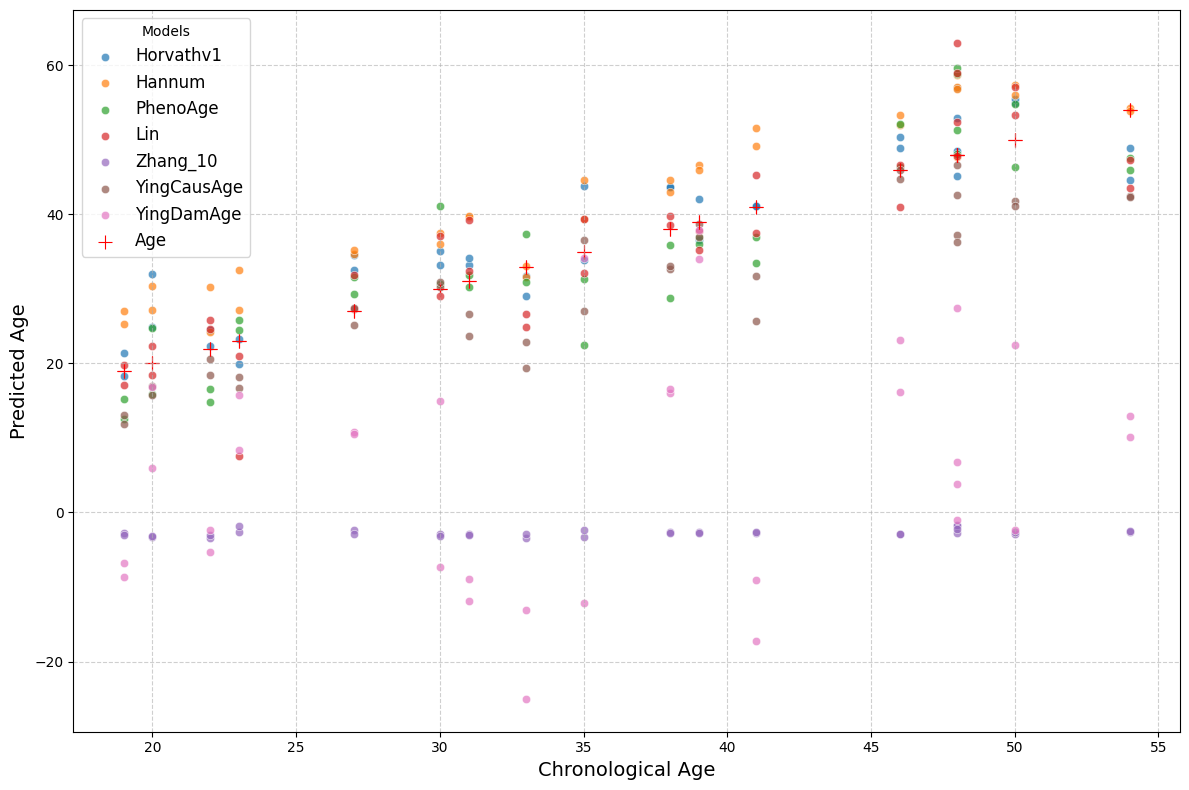

<Figure size 640x480 with 0 Axes>

In [33]:
# DunedinPACE is intentionally excluded here: it outputs a dimensionless pace-of-aging rate,
# not years, so plotting it alongside year-predicting clocks would be meaningless.
age_clock_names = ["Horvathv1", "Hannum", "PhenoAge", "Lin", "Zhang_10", "YingCausAge", "YingDamAge"]
age_models = [gallery.get(name) for name in age_clock_names]

print("Dataset 1: GSE120307")
plot_age_prediction(models=age_models, data=data1)
plt.suptitle("Age Prediction vs Chronological Age — GSE120307", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/age_prediction_GSE120307.png", dpi=150, bbox_inches='tight')
plt.show()

Dataset 2: GSE41169


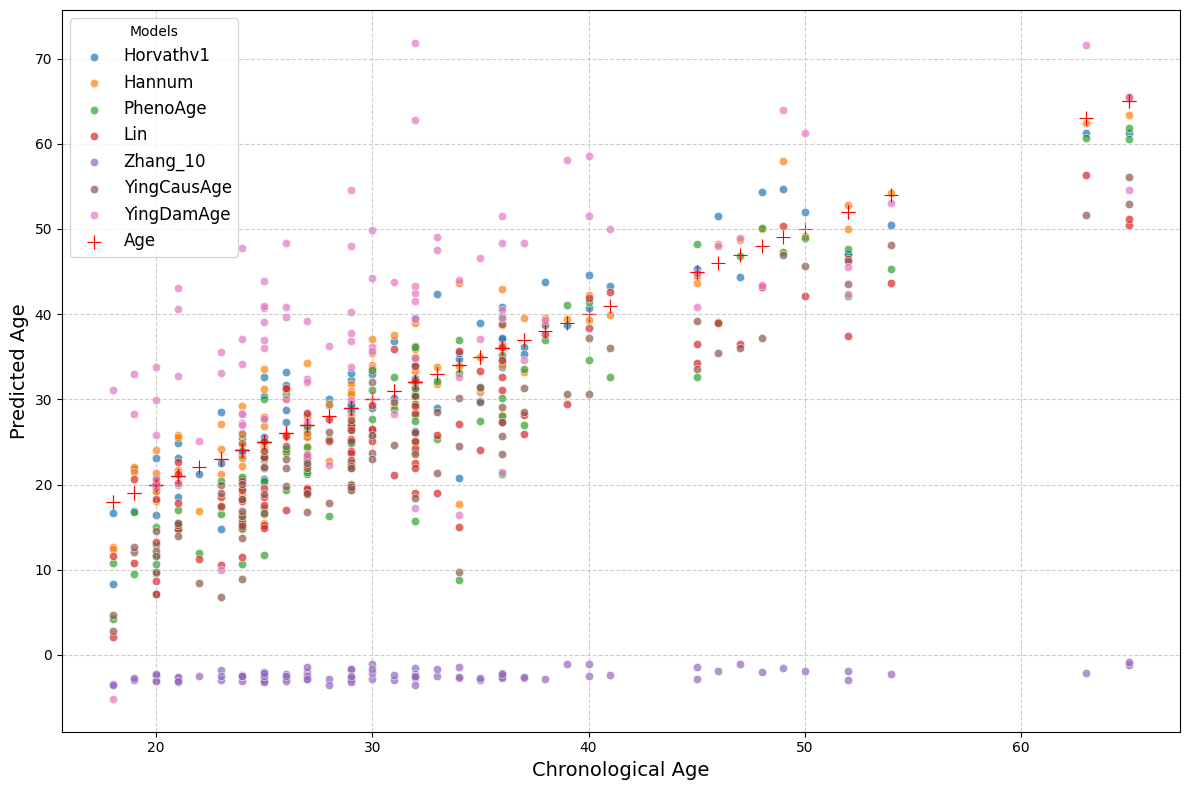

<Figure size 640x480 with 0 Axes>

In [34]:
print("Dataset 2: GSE41169")
plot_age_prediction(models=age_models, data=data2)
plt.suptitle("Age Prediction vs Chronological Age — GSE41169", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/age_prediction_GSE41169.png", dpi=150, bbox_inches='tight')
plt.show()

## Age Deviation Heatmap

This heatmap shows for each sample (rows) and each clock (columns) how much the clock's predicted age deviates from the sample's actual chronological age. The deviation is simply predicted age minus chronological age. Warm colors (positive) mean the clock thinks the sample is biologically older than their real age. Cool colors (negative) mean the clock thinks the sample is biologically younger. This lets us spot both systematic clock biases and individual samples that are consistently flagged as accelerated or decelerated agers across multiple clocks.

Dataset 1: GSE120307


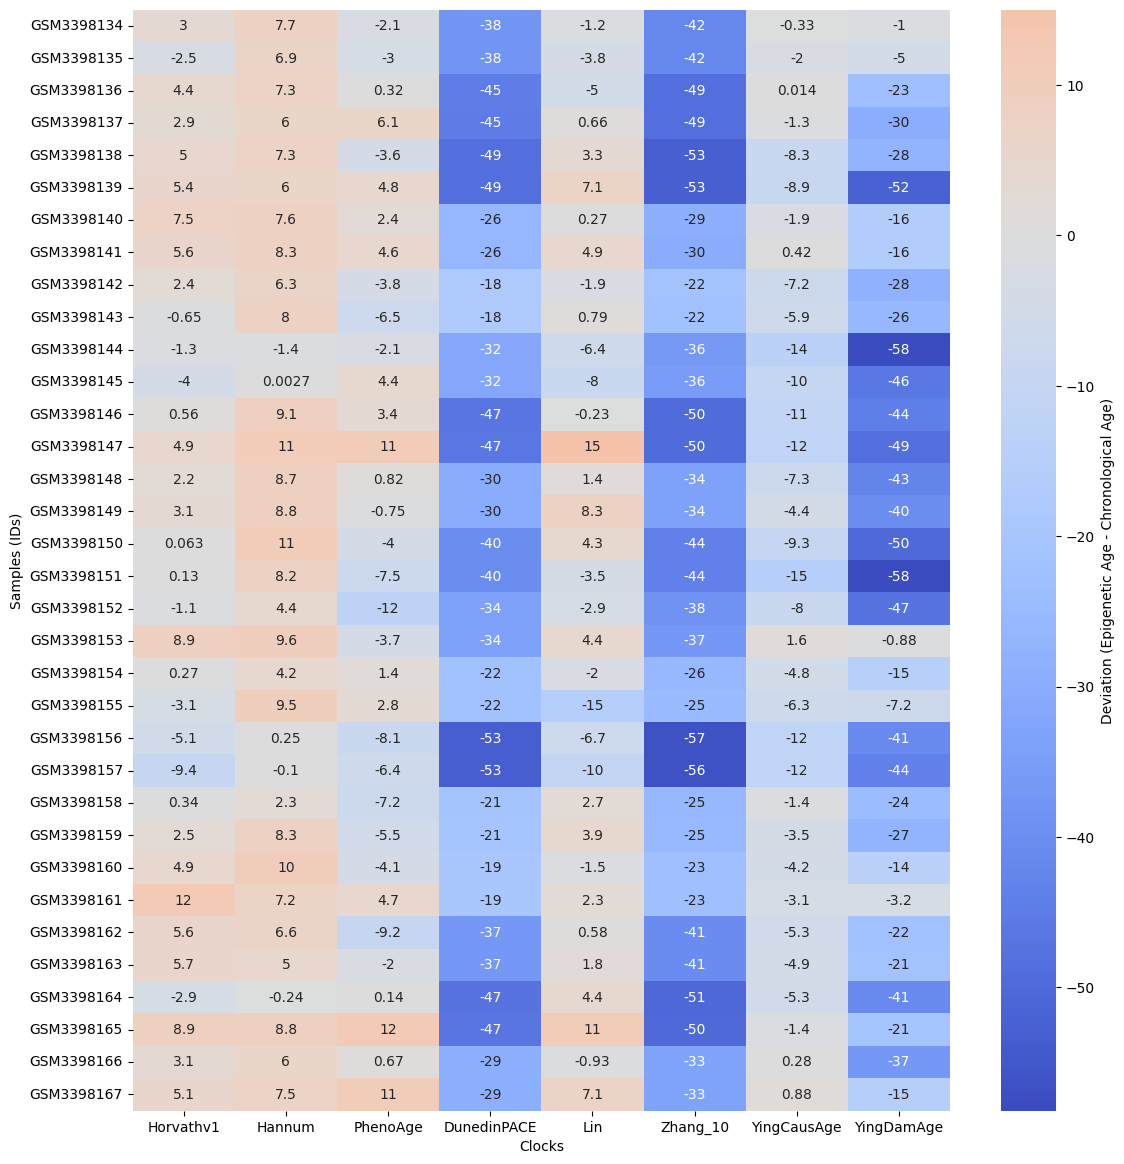

<Figure size 640x480 with 0 Axes>

In [35]:
print("Dataset 1: GSE120307")
plot_clock_deviation_heatmap(models=models, data=data1)
plt.suptitle("Age Deviation Heatmap — GSE120307", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/deviation_heatmap_GSE120307.png", dpi=150, bbox_inches='tight')
plt.show()

Dataset 2: GSE41169


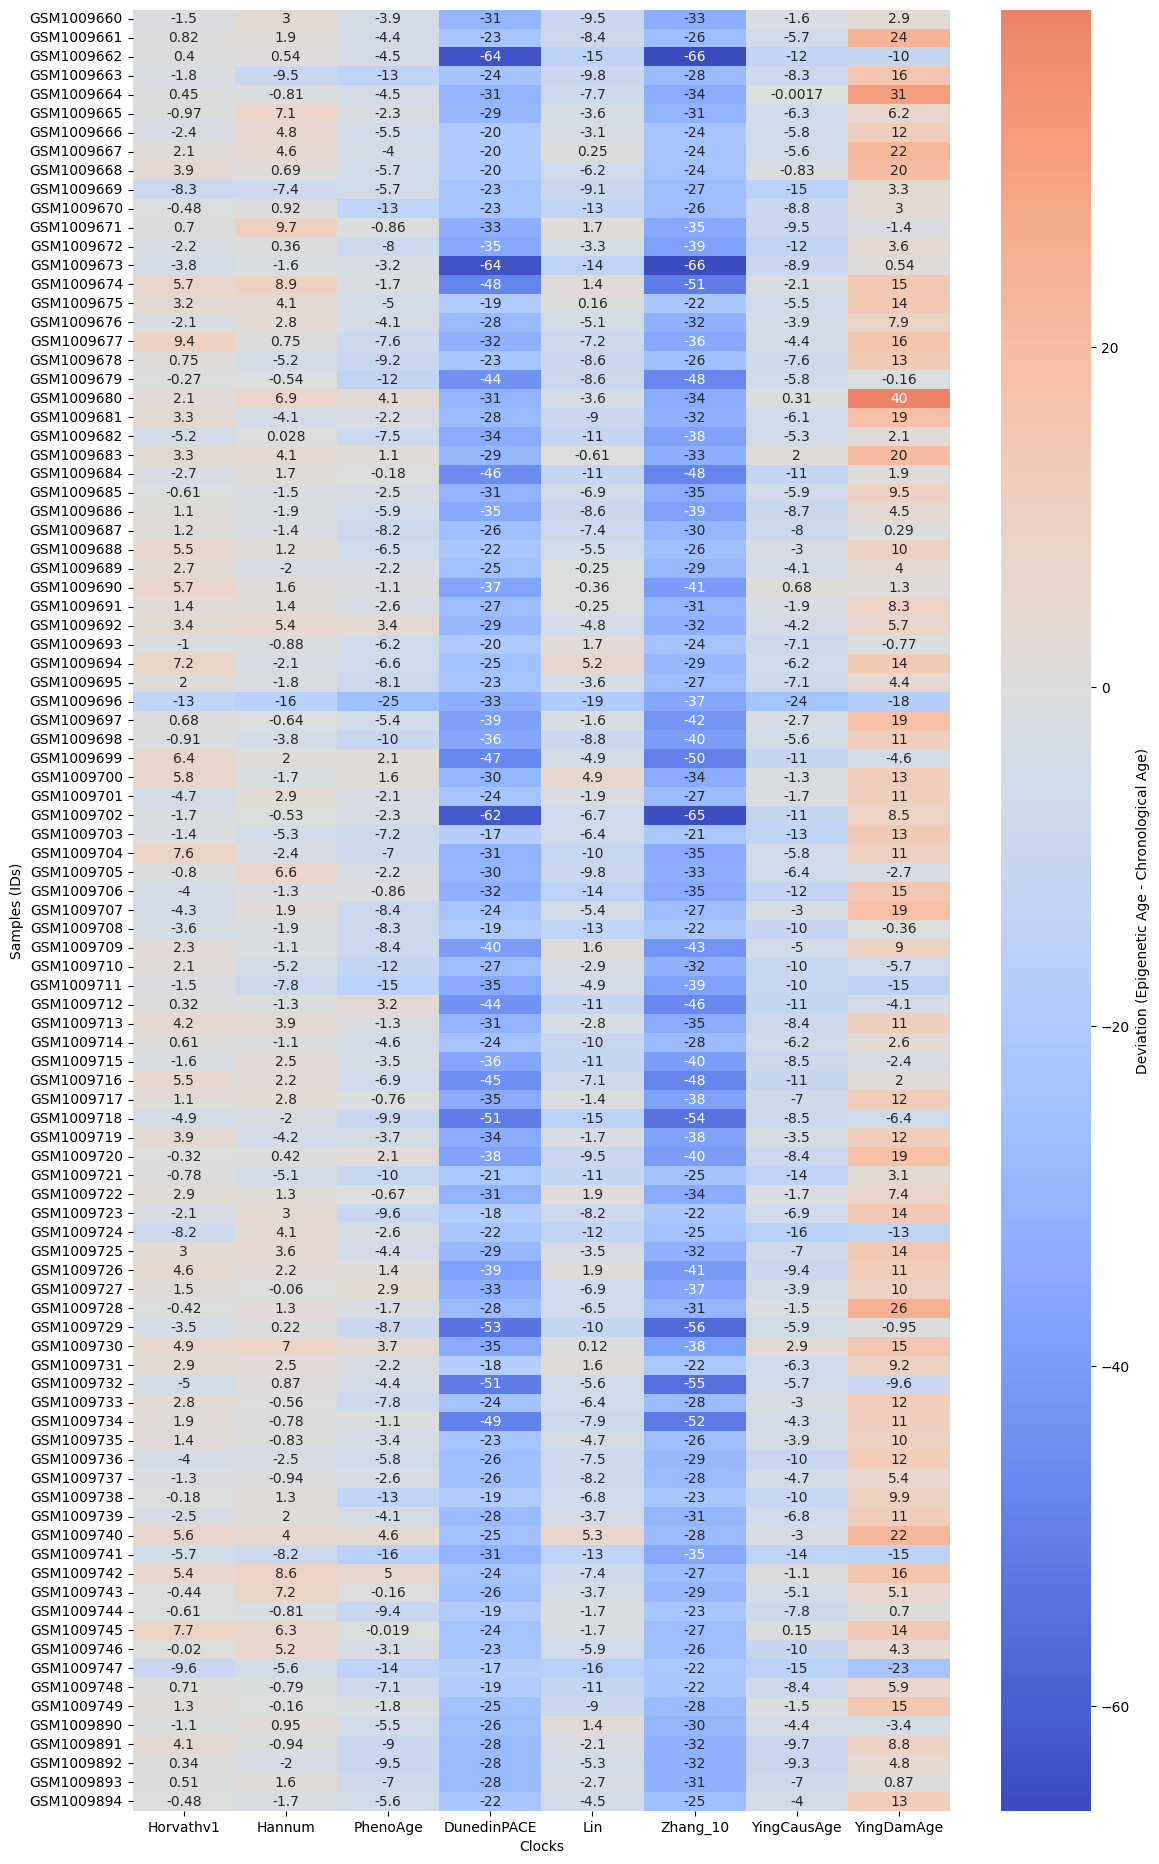

<Figure size 640x480 with 0 Axes>

In [36]:
print("Dataset 2: GSE41169")
plot_clock_deviation_heatmap(models=models, data=data2)
plt.suptitle("Age Deviation Heatmap — GSE41169", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/deviation_heatmap_GSE41169.png", dpi=150, bbox_inches='tight')
plt.show()

## Caching Clock Predictions

Rather than calling `model.predict()` redundantly in both the MAE and distribution cells, we run each prediction once here and store results in a dictionary. This avoids running predictions 3–4× per clock and makes the subsequent analysis cells faster.


In [37]:
# Run all predictions once and cache for reuse in MAE + box plot cells below
predictions = {}  # predictions[clock_name][dataset_label] = pd.Series of predicted values

for name, model in zip(age_clock_names, age_models):
    predictions[name] = {}
    for label, data in [("GSE120307", data1), ("GSE41169", data2)]:
        try:
            result = model.predict(data)
            predictions[name][label] = result.iloc[:, 0]
        except Exception as e:
            print(f"  Skipping {name} on {label}: {e}")
            predictions[name][label] = None

print("Prediction caching complete.")


Prediction caching complete.


## Comparing Mean Absolute Error Across Clocks

To quantitatively benchmark how accurate each clock is at predicting chronological age, we compute the Mean Absolute Error (MAE) for each clock on both datasets. MAE tells us on average how many years off a clock's prediction is from the true age. Lower MAE means better accuracy. This lets us directly compare clock performance across the two datasets.

             GSE120307  GSE41169
Horvathv1         3.96      2.95
Hannum            6.45      3.05
PhenoAge          4.77      5.57
Lin               4.53      6.36
Zhang_10         38.27     33.99
YingCausAge       5.68      6.76
YingDamAge       29.24     10.21


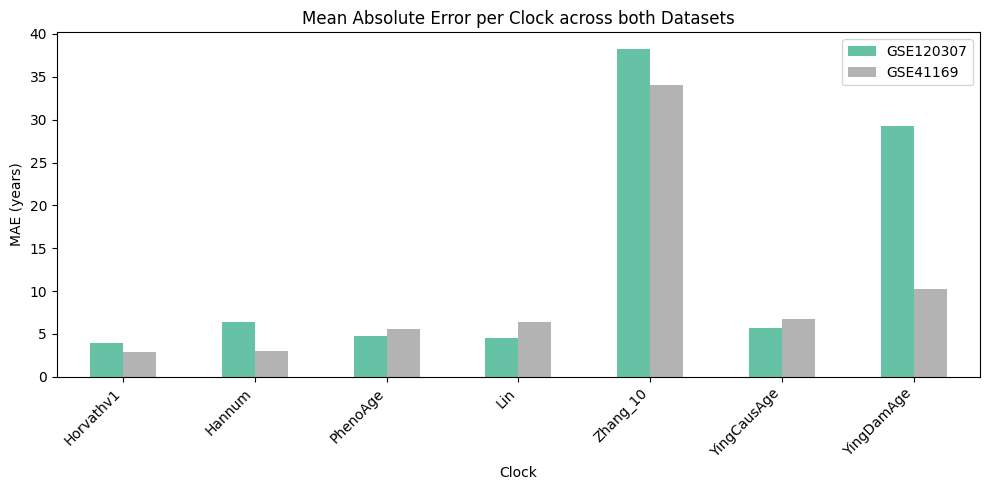

In [38]:
mae_results = {}
for name in age_clock_names:
    row = {}
    for label, data in [("GSE120307", data1), ("GSE41169", data2)]:
        pred = predictions[name].get(label)
        if pred is None:
            continue
        actual = data.metadata['age']
        common = pred.index.intersection(actual.index)
        row[label] = round(np.mean(np.abs(pred[common] - actual[common])), 2)
    if row:
        mae_results[name] = row

mae_df = pd.DataFrame(mae_results).T
print(mae_df)

mae_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title("Mean Absolute Error per Clock across both Datasets")
plt.ylabel("MAE (years)")
plt.xlabel("Clock")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("figures/mae_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


## Distribution of Predicted Ages per Clock

These box plots show the distribution of predicted ages from each clock across all samples in each dataset. This helps us see whether a clock has a wide or narrow prediction range, and whether it is well calibrated to the actual age distribution of the dataset. A clock whose box plot is roughly centered on the actual age range of the dataset is better calibrated than one that consistently predicts too high or too low.

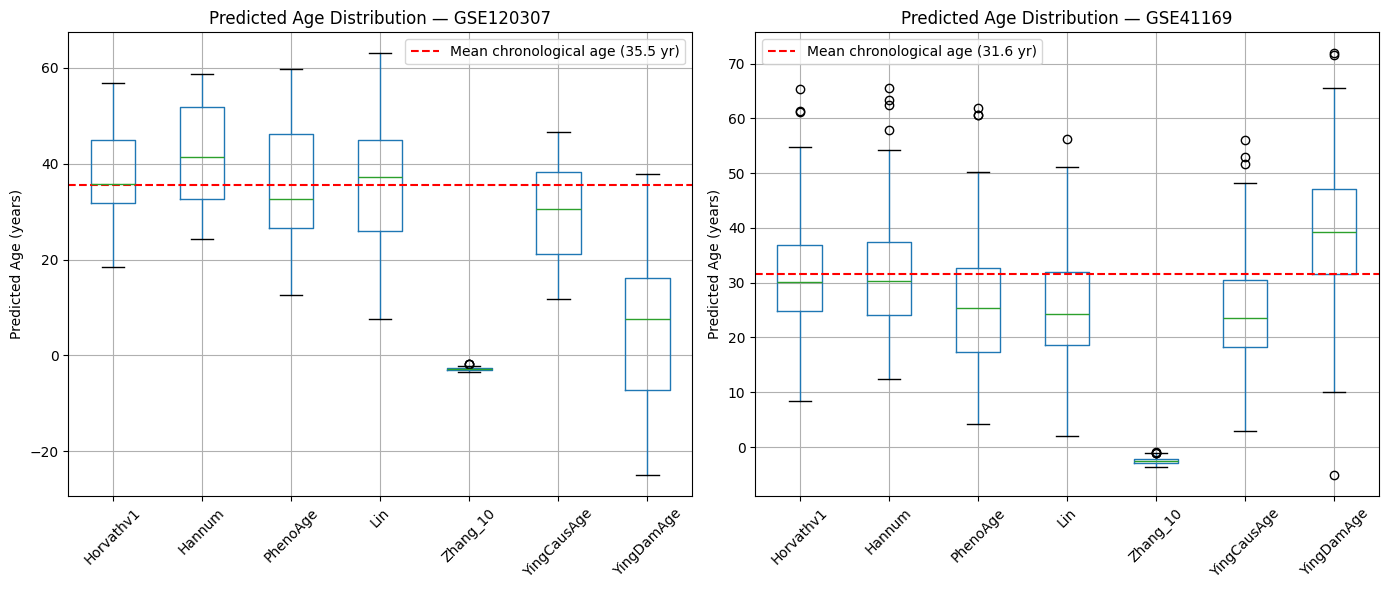

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, data) in zip(axes, [("GSE120307", data1), ("GSE41169", data2)]):
    preds = {name: predictions[name][label].values
             for name in age_clock_names
             if predictions[name].get(label) is not None}
    pred_df = pd.DataFrame(preds)
    pred_df.boxplot(ax=ax, rot=45)
    ax.axhline(y=data.metadata['age'].mean(), color='red', linestyle='--',
               label=f'Mean chronological age ({data.metadata["age"].mean():.1f} yr)')
    ax.set_title(f"Predicted Age Distribution — {label}")
    ax.set_ylabel("Predicted Age (years)")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/predicted_age_distributions.png", dpi=150, bbox_inches='tight')
plt.show()


## Discussion and Interpretation

### Inter-Clock Correlations
As expected, the first-generation chronological clocks—Horvathv1 and Hannum—show strong mutual correlation in both datasets. Both were trained on Illumina 450k blood methylation data to predict chronological age, so their rankings of samples are largely consistent. PhenoAge, despite being a second-generation clock, also correlates reasonably well with Horvathv1 and Hannum, reflecting its underlying dependence on methylation patterns that shift with age, even though it was optimised for phenotypic rather than chronological age.

DunedinPACE consistently shows the lowest correlations with all other clocks. This is expected and biologically meaningful: DunedinPACE measures the *rate* at which someone is aging (a dimensionless number around 1.0 for average), not their absolute predicted age in years. Comparing it directly with year-predicting clocks would be category confusion.

### Prediction Accuracy (MAE)
Across both datasets, Zhang_10 typically exhibits higher MAE despite—or because of—using only 10 CpGs. Its minimal marker set makes it fast and practical for mortality-risk screening, but at the cost of per-sample accuracy. Horvathv1 and Hannum tend to produce lower MAE on blood samples, consistent with their training on large blood cohorts.

The second-generation clocks (PhenoAge, YingCausAge, YingDamAge) show comparable or slightly worse MAE for chronological age prediction—this is expected since they were not explicitly optimised for chronological accuracy but for biologically meaningful aging signals.

### Cross-Dataset Consistency
The inter-clock relationships observed in GSE120307 broadly replicate in GSE41169, suggesting the correlation structure is a property of the clocks themselves rather than an artefact of one particular cohort. Some differences in MAE across the two datasets likely reflect genuine cohort differences (age-range composition, population ancestry, technical batch effects) rather than clock instability.

### Regression to the Mean
The scatter plots reveal the classic regression-to-the-mean pattern in many clocks: very young samples tend to be predicted older than they are, and very old samples younger. This is a structural limitation of linear models trained on unbalanced age distributions—a known open problem in the epigenetic clock literature.

### Conclusion
No single clock dominates across all metrics. Horvathv1 and Hannum remain strong baselines for chronological age. PhenoAge adds phenotypic relevance. DunedinPACE provides a fundamentally different and complementary view of aging dynamics. The choice of clock should be driven by the biological question: predicting absolute age, identifying accelerated aging in individuals, or estimating mortality risk.
